# Visibility Timing Evaluator

This notebook evaluates the visibility-timing experiments generated by the four running scripts:

- `G_send_to_G_visibility_timing.py` → `gg_*`
- `G_send_to_S_visibility_timing.py` → `gs_*`
- `S_send_to_G_visibility_timing.py` → `sg_*`
- `S_send_to_S_visibility_timing.py` → `ss_*`

The evaluator is aligned with the current timing-script output convention:

- `K_list = [1, 2, 3, 4, 5, 6, 7, 8]`
- `visibility_start_list = [0, 25, 50, 75, 100, 125, 150, 175, 200]`
- file format: `{prefix}_visibility_start_{visibility_start}_{dv}_across_K_size_{agent_num}`

Smaller breakthrough rank means a better solution, so rank figures invert the y-axis.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
legend_properties = {'weight':'bold'}
nus_blue = "#003D7C"
nus_orange = "#EF7C00"
# Nature three colors
nature_orange = "#F16C23"
nature_blue = "#2B6A99"
nature_green = "#1B7C3D"
# Morandi six colors
morandi_blue = "#046586"
morandi_green =  "#28A9A1"
morandi_yellow = "#C9A77C"
morandi_orange = "#F4A016"
morandi_pink = "#F6BBC6"
morandi_red = "#E71F19"
morandi_purple = "#B08BEB"
# Others
shallow_grey = "#D3D4D3"
deep_grey = "#A6ABB6"
# Red and Blue
strong_red = "#A61C5D"
strong_blue = "#1B64A4"

# Shallow-deep pair
shallow_purple = "#EAD7EA"
deep_purple = "#BA9DB9"
shallow_cyan = "#A9D5E0"
deep_cyan = "#48C0BF"
shallow_blue = "#B6DAEC"
deep_blue = "#98CFE4"
shallow_pink = "#F5E0E5"
deep_pink = "#E5A7B6"
shallow_green = "#C2DED0"
deep_green = "#A5C6B1"

color_pairs = [[shallow_purple, deep_purple],  [shallow_green, deep_green],
               [shallow_blue, deep_blue], [shallow_pink, deep_pink], [shallow_cyan, deep_cyan],
               [shallow_grey, deep_grey]]
morandi_colors = [morandi_blue, morandi_green, morandi_yellow, morandi_orange, morandi_pink, morandi_red, morandi_purple]
import os
from pathlib import Path


import re


In [2]:
from pathlib import Path
import pickle
import re
import numpy as np

# =========================
# Configuration
# =========================
# IMPORTANT:
# Set this to the folder that contains the output files produced by the running scripts.
# The scripts save files relative to their current working directory unless you explicitly
# move them into this folder.
result_folder = Path(r"/Volumes/T7/data/gst-0112-26/Timing_3")

agent_num = 200

# These two lists now match the uploaded G_send_to_G_visibility_timing.py script.
# If you later change the scripts, update these lists accordingly.
K_list = [1, 2, 3, 4, 5, 6, 7, 8]
visibility_start_list = [0, 25, 50, 75, 100, 125, 150, 175, 200]

condition_order = ["gg", "gs", "sg", "ss"]
condition_labels = {
    "gg": "G → G",
    "gs": "G → S",
    "sg": "S → G",
    "ss": "S → S",
}

dv_order = ["breakthrough_fitness", "breakthrough_rank", "diversity"]
dv_labels = {
    "breakthrough_rank": "Best solution rank",
    "breakthrough_fitness": "Best solution fitness",
    "diversity": "Diversity",
}

# If True, the notebook uses the visibility-start values found in result_folder
# rather than the manually specified visibility_start_list above.
# This is useful after changing timing windows in the running scripts.
AUTO_DETECT_VISIBILITY_STARTS = True

# If True, stop immediately when expected files are missing or saved arrays have
# a different K dimension from K_list.
LOAD_STRICT = True

file_pattern = re.compile(
    r"^(?P<prefix>gg|gs|sg|ss)_visibility_start_(?P<start>\d+)_"
    r"(?P<dv>breakthrough_fitness|breakthrough_rank|diversity)_"
    r"across_K_size_(?P<agent_num>\d+)$"
)

condition_colors = {
    "gg": morandi_blue,
    "gs": morandi_orange,
    "sg": morandi_green,
    "ss": morandi_purple,
}

def load_pickle(path):
    with open(path, "rb") as infile:
        return pickle.load(infile)

def result_file(prefix, visibility_start, dv):
    return result_folder / f"{prefix}_visibility_start_{visibility_start}_{dv}_across_K_size_{agent_num}"

def scan_available_results(folder):
    """Return a list of parsed result-file records from the result folder."""
    records = []
    if not folder.exists():
        return records

    for path in folder.iterdir():
        match = file_pattern.match(path.name)
        if match is None:
            continue

        record = match.groupdict()
        record["start"] = int(record["start"])
        record["agent_num"] = int(record["agent_num"])
        record["path"] = path
        records.append(record)

    return records

# =========================
# Diagnose available files
# =========================
print("Result folder:", result_folder)
print("Folder exists:", result_folder.exists())

available_records = scan_available_results(result_folder)
available_records = [r for r in available_records if r["agent_num"] == agent_num]

print("Number of matching result files:", len(available_records))

if available_records:
    starts_by_prefix_dv = {}
    for r in available_records:
        key = (r["prefix"], r["dv"])
        starts_by_prefix_dv.setdefault(key, set()).add(r["start"])

    print("\nAvailable visibility starts by prefix and DV:")
    for prefix in condition_order:
        for dv in dv_order:
            starts = sorted(starts_by_prefix_dv.get((prefix, dv), []))
            print(f"  {prefix:>2} | {dv:<20}: {starts}")

    if AUTO_DETECT_VISIBILITY_STARTS:
        required_keys = [(prefix, dv) for prefix in condition_order for dv in dv_order]
        common_starts = None
        for key in required_keys:
            starts = starts_by_prefix_dv.get(key, set())
            common_starts = starts if common_starts is None else common_starts & starts

        if common_starts:
            visibility_start_list = sorted(common_starts)
            print("\nAUTO_DETECT_VISIBILITY_STARTS=True")
            print("Using common visibility_start_list found in files:", visibility_start_list)
        else:
            print("\nAUTO_DETECT_VISIBILITY_STARTS=True but no common start values were found")
            print("across all four prefixes and all DVs.")
            print("Using manually configured visibility_start_list:", visibility_start_list)
else:
    print("\nNo matching result files found.")
    print("Check that result_folder points to the directory where the scripts saved outputs.")

print("\nConfigured K_list:", K_list)
print("Number of K values expected:", len(K_list))
print("Visibility starts used for loading:", visibility_start_list)

# =========================
# Load results
# =========================
def load_visibility_timing_results(prefixes=condition_order, strict=LOAD_STRICT):
    data = {}
    missing_files = []
    wrong_k_dimension = []

    for prefix in prefixes:
        data[prefix] = {}

        for dv in dv_order:
            rows = []

            for visibility_start in visibility_start_list:
                path = result_file(prefix, visibility_start, dv)

                if not path.exists():
                    missing_files.append(path)
                    rows.append(np.full(len(K_list), np.nan))
                    continue

                values = np.asarray(load_pickle(path), dtype=float).reshape(-1)

                if len(values) != len(K_list):
                    wrong_k_dimension.append((path.name, len(values), len(K_list)))
                    if len(values) < len(K_list):
                        values = np.pad(values, (0, len(K_list) - len(values)), constant_values=np.nan)
                    else:
                        values = values[:len(K_list)]

                rows.append(values)

            data[prefix][dv] = np.vstack(rows)

    if missing_files:
        print("\nMissing files:")
        for path in missing_files[:40]:
            print("  -", Path(path).name)
        if len(missing_files) > 40:
            print(f"  ... and {len(missing_files) - 40} more")

    if wrong_k_dimension:
        print("\nK-dimension mismatches:")
        for name, observed, expected in wrong_k_dimension[:40]:
            print(f"  - {name}: observed {observed}, expected {expected}")
        if len(wrong_k_dimension) > 40:
            print(f"  ... and {len(wrong_k_dimension) - 40} more")

    if strict and (missing_files or wrong_k_dimension):
        raise FileNotFoundError(
            "Result loading failed. Most likely causes: "
            "(1) result_folder is not the directory where the scripts saved outputs; "
            "(2) visibility_start_list in the evaluator does not match the scripts; "
            "(3) K_list in the evaluator does not match the saved array length; "
            "(4) one or more direction scripts have not finished."
        )

    return data

data = load_visibility_timing_results(strict=LOAD_STRICT)

# Quick shape check
print("\nLoaded data shapes:")
for prefix in condition_order:
    for dv in dv_order:
        print(prefix, dv, data[prefix][dv].shape)


Result folder: /Volumes/T7/data/gst-0112-26/Timing_3
Folder exists: True
Number of matching result files: 108

Available visibility starts by prefix and DV:
  gg | breakthrough_fitness: [0, 25, 50, 75, 100, 125, 150, 175, 200]
  gg | breakthrough_rank   : [0, 25, 50, 75, 100, 125, 150, 175, 200]
  gg | diversity           : [0, 25, 50, 75, 100, 125, 150, 175, 200]
  gs | breakthrough_fitness: [0, 25, 50, 75, 100, 125, 150, 175, 200]
  gs | breakthrough_rank   : [0, 25, 50, 75, 100, 125, 150, 175, 200]
  gs | diversity           : [0, 25, 50, 75, 100, 125, 150, 175, 200]
  sg | breakthrough_fitness: [0, 25, 50, 75, 100, 125, 150, 175, 200]
  sg | breakthrough_rank   : [0, 25, 50, 75, 100, 125, 150, 175, 200]
  sg | diversity           : [0, 25, 50, 75, 100, 125, 150, 175, 200]
  ss | breakthrough_fitness: [0, 25, 50, 75, 100, 125, 150, 175, 200]
  ss | breakthrough_rank   : [0, 25, 50, 75, 100, 125, 150, 175, 200]
  ss | diversity           : [0, 25, 50, 75, 100, 125, 150, 175, 200]

AU

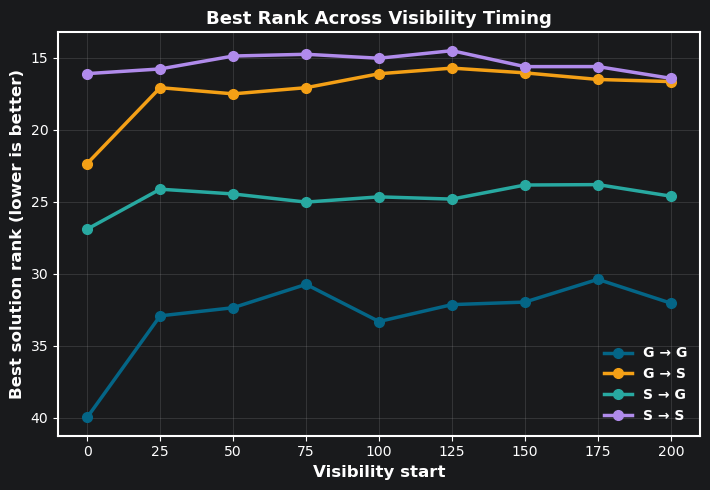

Saved: /Volumes/T7/data/gst-0112-26/Timing_3/figure_1_best_rank_across_visibility_timing.png


In [3]:
# =========================
# Figure 1: Best solution rank across visibility timing
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.spines["left"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

x = visibility_start_list
for prefix in condition_order:
    # Average across K to show the main timing pattern.
    y = data[prefix]["breakthrough_rank"].mean(axis=1)
    ax.plot(x, y, marker="o", linewidth=2.5, markersize=7,
            label=condition_labels[prefix], color=condition_colors[prefix])

ax.invert_yaxis()  # smaller rank means better solution; invert so better is visually higher
ax.set_xlabel("Visibility start", fontweight="bold", fontsize=12)
ax.set_ylabel("Best solution rank (lower is better)", fontweight="bold", fontsize=12)
ax.set_title("Best Rank Across Visibility Timing", fontweight="bold", fontsize=13)
ax.legend(frameon=False, prop=legend_properties)
ax.grid(alpha=0.25)
plt.tight_layout()

output_path = result_folder / "figure_1_best_rank_across_visibility_timing.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output_path)


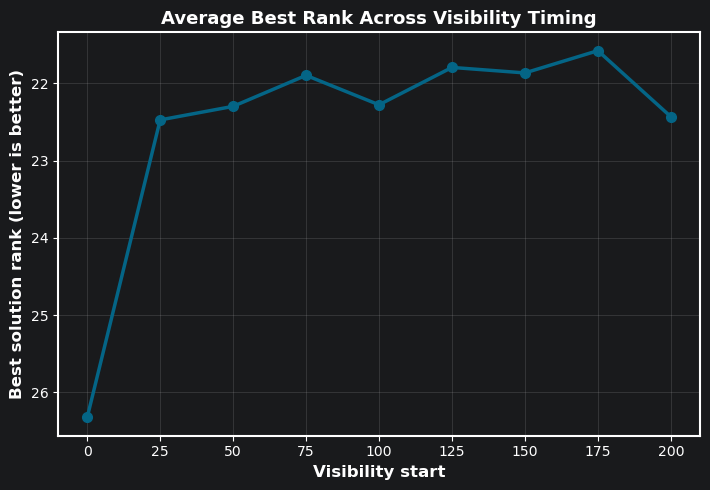

Saved: /Volumes/T7/data/gst-0112-26/Timing_3/figure_2_average_best_rank_across_visibility_timing.png


In [4]:
# =========================
# Figure 2: Best solution rank across visibility timing, averaged across all directions
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.spines["left"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

x = visibility_start_list

# Average across both K and the four G-S visibility conditions.
y = np.mean([data[prefix]["breakthrough_rank"].mean(axis=1) for prefix in condition_order], axis=0)

ax.plot(x, y, marker="o", linewidth=2.5, markersize=7, color=morandi_blue)

ax.invert_yaxis()
ax.set_xlabel("Visibility start", fontweight="bold", fontsize=12)
ax.set_ylabel("Best solution rank (lower is better)", fontweight="bold", fontsize=12)
ax.set_title("Average Best Rank Across Visibility Timing", fontweight="bold", fontsize=13)
ax.grid(alpha=0.25)
plt.tight_layout()

output_path = result_folder / "figure_2_average_best_rank_across_visibility_timing.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output_path)


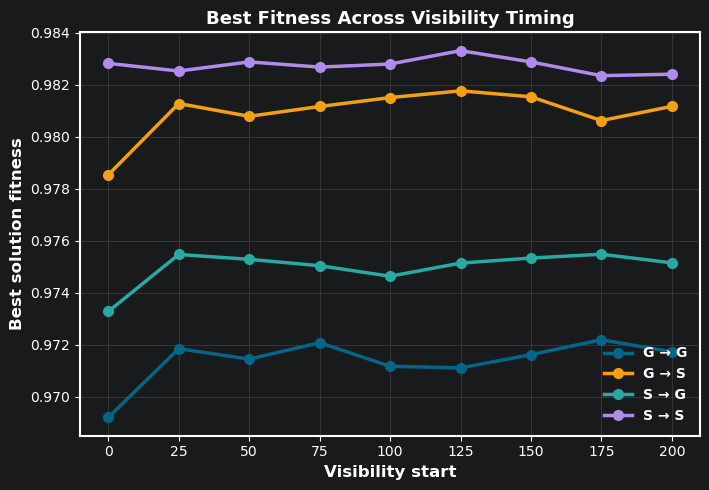

Saved: /Volumes/T7/data/gst-0112-26/Timing_3/figure_3_best_fitness_across_visibility_timing.png


In [5]:
# =========================
# Figure 3: Best solution fitness across visibility timing
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.spines["left"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

x = visibility_start_list
for prefix in condition_order:
    y = data[prefix]["breakthrough_fitness"].mean(axis=1)
    ax.plot(x, y, marker="o", linewidth=2.5, markersize=7,
            label=condition_labels[prefix], color=condition_colors[prefix])

ax.set_xlabel("Visibility start", fontweight="bold", fontsize=12)
ax.set_ylabel("Best solution fitness", fontweight="bold", fontsize=12)
ax.set_title("Best Fitness Across Visibility Timing", fontweight="bold", fontsize=13)
ax.legend(frameon=False, prop=legend_properties)
ax.grid(alpha=0.25)
plt.tight_layout()

output_path = result_folder / "figure_3_best_fitness_across_visibility_timing.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output_path)


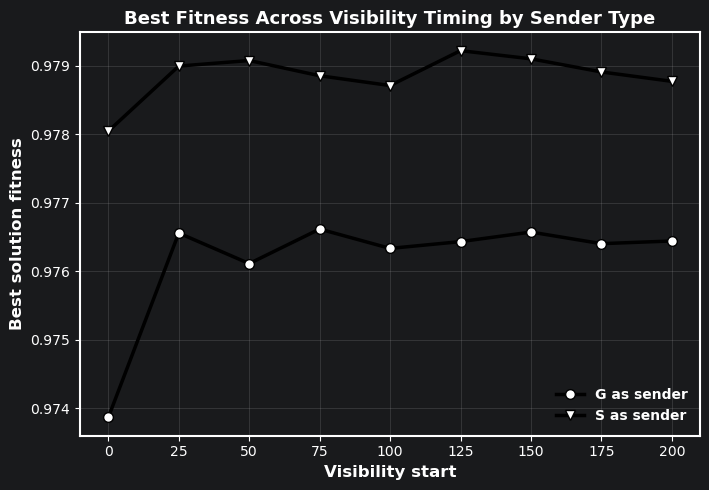

Saved: /Volumes/T7/data/gst-0112-26/Timing_3/figure_4_best_fitness_by_sender_type.png


In [6]:
# =========================
# Figure 4: Best solution fitness by sender type
# G sender = average of GG and GS
# S sender = average of SS and SG
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.spines["left"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

x = visibility_start_list

# Average across receiver types, then average across K.
y_g_sender = np.mean([
    data["gg"]["breakthrough_fitness"],
    data["gs"]["breakthrough_fitness"]
], axis=0).mean(axis=1)

y_s_sender = np.mean([
    data["ss"]["breakthrough_fitness"],
    data["sg"]["breakthrough_fitness"]
], axis=0).mean(axis=1)

ax.plot(
    x, y_g_sender, "-o",
    linewidth=2.5, markersize=7,
    color="black", markerfacecolor="white",
    label="G as sender"
)

ax.plot(
    x, y_s_sender, "-v",
    linewidth=2.5, markersize=7,
    color="black", markerfacecolor="white",
    label="S as sender"
)

ax.set_xlabel("Visibility start", fontweight="bold", fontsize=12)
ax.set_ylabel("Best solution fitness", fontweight="bold", fontsize=12)
ax.set_title("Best Fitness Across Visibility Timing by Sender Type",
             fontweight="bold", fontsize=13)

ax.legend(frameon=False, prop=legend_properties)
ax.grid(alpha=0.25)
plt.tight_layout()

output_path = result_folder / "figure_4_best_fitness_by_sender_type.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output_path)


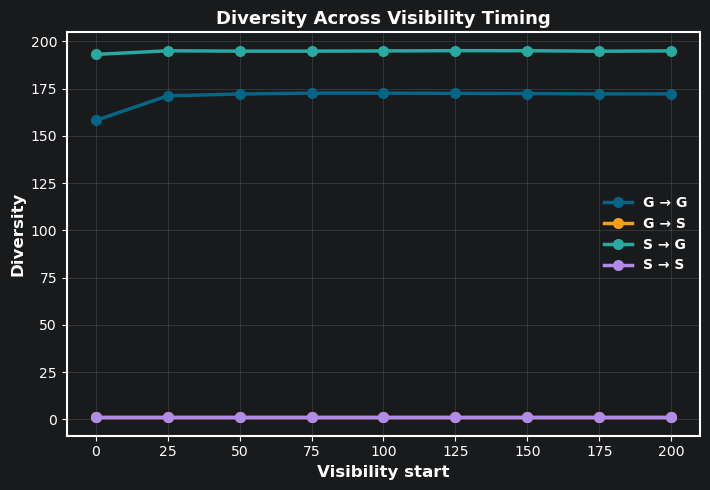

Saved: /Volumes/T7/data/gst-0112-26/Timing_3/figure_5_diversity_across_visibility_timing.png


In [7]:
# =========================
# Figure 5: Diversity across visibility timing
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.spines["left"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

x = visibility_start_list
for prefix in condition_order:
    y = data[prefix]["diversity"].mean(axis=1)
    ax.plot(x, y, marker="o", linewidth=2.5, markersize=7,
            label=condition_labels[prefix], color=condition_colors[prefix])

ax.set_xlabel("Visibility start", fontweight="bold", fontsize=12)
ax.set_ylabel("Diversity", fontweight="bold", fontsize=12)
ax.set_title("Diversity Across Visibility Timing", fontweight="bold", fontsize=13)
ax.legend(frameon=False, prop=legend_properties)
ax.grid(alpha=0.25)
plt.tight_layout()

output_path = result_folder / "figure_5_diversity_across_visibility_timing.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output_path)


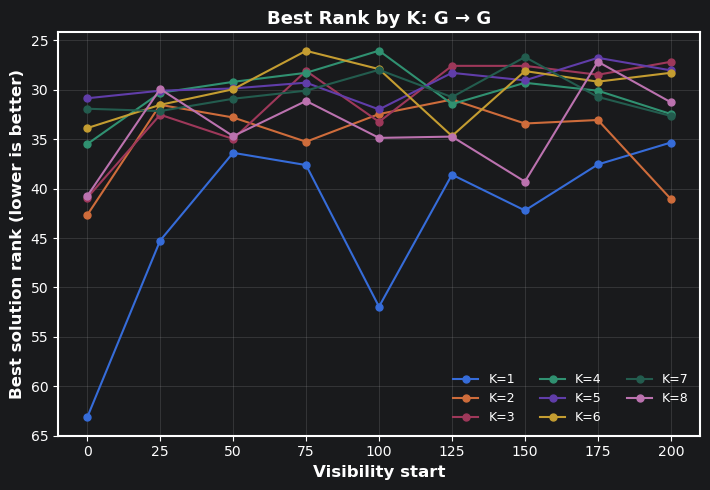

Saved: /Volumes/T7/data/gst-0112-26/Timing_3/figure_6_gg_best_rank_by_K_across_visibility_timing.png


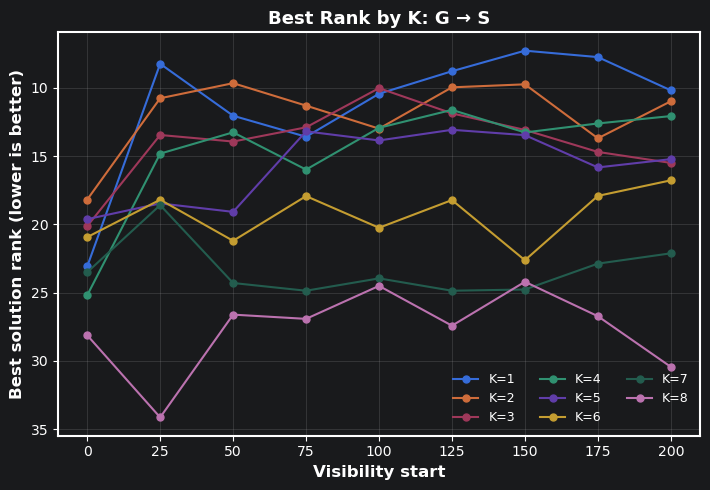

Saved: /Volumes/T7/data/gst-0112-26/Timing_3/figure_6_gs_best_rank_by_K_across_visibility_timing.png


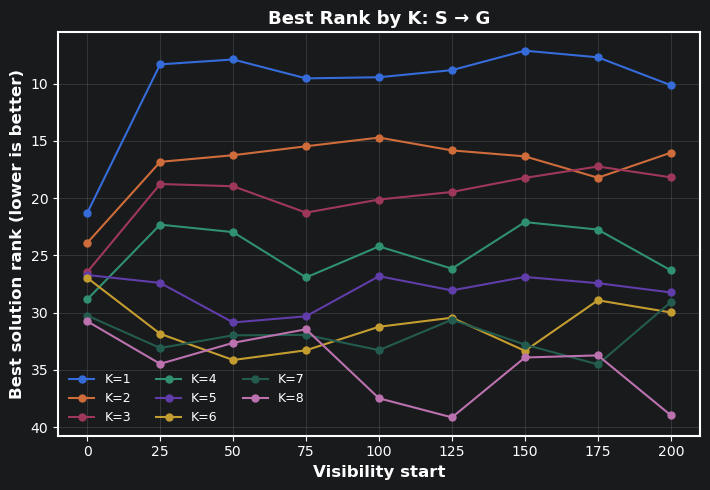

Saved: /Volumes/T7/data/gst-0112-26/Timing_3/figure_6_sg_best_rank_by_K_across_visibility_timing.png


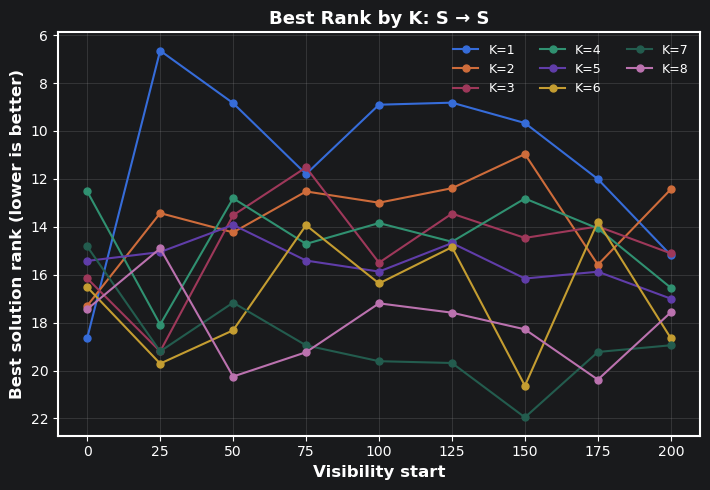

Saved: /Volumes/T7/data/gst-0112-26/Timing_3/figure_6_ss_best_rank_by_K_across_visibility_timing.png


In [8]:
# =========================
# Figure 6: Detailed rank patterns by K
# =========================
# This figure helps diagnose whether the main timing pattern is driven by low-K or high-K landscapes.
for prefix in condition_order:
    fig, ax = plt.subplots(figsize=(7.2, 5.0))
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["right"].set_linewidth(1.5)
    ax.spines["top"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)

    for k_index, K in enumerate(K_list):
        y = data[prefix]["breakthrough_rank"][:, k_index]
        ax.plot(visibility_start_list, y, marker="o", linewidth=1.5, markersize=5, label=f"K={K}")

    ax.invert_yaxis()
    ax.set_xlabel("Visibility start", fontweight="bold", fontsize=12)
    ax.set_ylabel("Best solution rank (lower is better)", fontweight="bold", fontsize=12)
    ax.set_title(f"Best Rank by K: {condition_labels[prefix]}", fontweight="bold", fontsize=13)
    ax.legend(frameon=False, ncol=3, fontsize=9)
    ax.grid(alpha=0.25)
    plt.tight_layout()

    output_path = result_folder / f"figure_6_{prefix}_best_rank_by_K_across_visibility_timing.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


In [9]:
# =========================
# Optional helper: inspect exact values as tables
# =========================
def timing_table(dv="breakthrough_rank", aggregate="mean"):
    """Return a condition-by-timing table for a selected DV.

    aggregate="mean" averages across K.
    aggregate=None returns the full arrays in data[prefix][dv].
    """
    if aggregate is None:
        return {prefix: data[prefix][dv] for prefix in condition_order}
    if aggregate != "mean":
        raise ValueError("Only aggregate='mean' or aggregate=None are supported.")

    table = []
    for prefix in condition_order:
        row = [condition_labels[prefix]] + data[prefix][dv].mean(axis=1).round(4).tolist()
        table.append(row)

    columns = ["Condition"] + [f"start={v}" for v in visibility_start_list]
    return table, columns

table, columns = timing_table("breakthrough_rank")
print(columns)
for row in table:
    print(row)

table, columns = timing_table("breakthrough_fitness")
print("\n", columns)
for row in table:
    print(row)


['Condition', 'start=0', 'start=25', 'start=50', 'start=75', 'start=100', 'start=125', 'start=150', 'start=175', 'start=200']
['G → G', 39.9588, 32.9131, 32.3481, 30.7269, 33.3062, 32.1331, 31.9569, 30.3794, 32.0312]
['G → S', 22.3419, 17.0781, 17.5069, 17.0794, 16.1131, 15.7212, 16.0506, 16.5075, 16.6569]
['S → G', 26.8931, 24.1231, 24.4538, 25.0188, 24.6556, 24.81, 23.8337, 23.8056, 24.6081]
['S → S', 16.1031, 15.7788, 14.8825, 14.7612, 15.0356, 14.5106, 15.6188, 15.615, 16.43]

 ['Condition', 'start=0', 'start=25', 'start=50', 'start=75', 'start=100', 'start=125', 'start=150', 'start=175', 'start=200']
['G → G', 0.9692, 0.9718, 0.9714, 0.9721, 0.9712, 0.9711, 0.9716, 0.9722, 0.9717]
['G → S', 0.9785, 0.9813, 0.9808, 0.9812, 0.9815, 0.9818, 0.9815, 0.9806, 0.9812]
['S → G', 0.9733, 0.9755, 0.9753, 0.975, 0.9746, 0.9751, 0.9753, 0.9755, 0.9751]
['S → S', 0.9828, 0.9825, 0.9829, 0.9827, 0.9828, 0.9833, 0.9829, 0.9823, 0.9824]


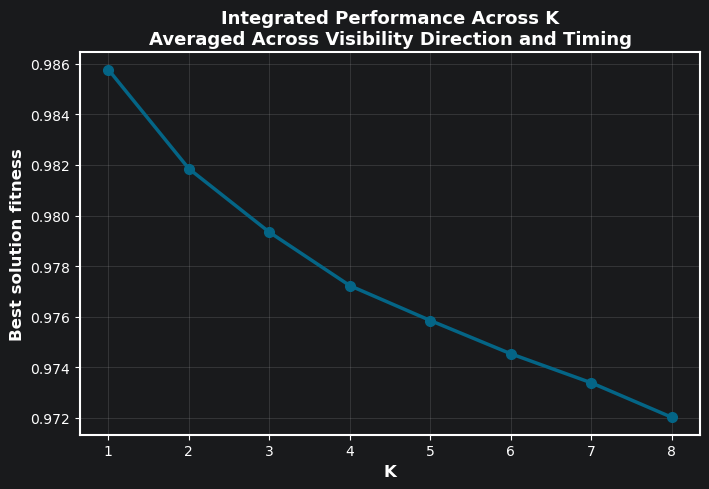

Saved: /Volumes/T7/data/gst-0112-26/Timing_3/figure_7_integrated_performance_across_K.png
Averaged performance across K:
K=1: 0.9858
K=2: 0.9819
K=3: 0.9793
K=4: 0.9772
K=5: 0.9758
K=6: 0.9745
K=7: 0.9734
K=8: 0.9720


In [10]:
# =========================
# Figure 7: Integrated performance across K
# Averaged across G/S visibility recombinations and visibility timing
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.spines["left"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

dv = "breakthrough_fitness"

# Stack arrays with shape:
# condition × visibility_start × K
performance_stack = np.stack(
    [data[prefix][dv] for prefix in condition_order],
    axis=0
)

# Average across:
# axis=0: G/S recombination conditions
# axis=1: visibility timing
# Remaining axis is K
performance_across_K = performance_stack.mean(axis=(0, 1))

ax.plot(
    K_list,
    performance_across_K,
    marker="o",
    linewidth=2.5,
    markersize=7,
    color=morandi_blue
)

ax.set_xlabel("K", fontweight="bold", fontsize=12)
ax.set_ylabel("Best solution fitness", fontweight="bold", fontsize=12)
ax.set_title(
    "Integrated Performance Across K\nAveraged Across Visibility Direction and Timing",
    fontweight="bold",
    fontsize=13
)
ax.grid(alpha=0.25)

plt.tight_layout()

output_path = result_folder / "figure_7_integrated_performance_across_K.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", output_path)
print("Averaged performance across K:")
for K, value in zip(K_list, performance_across_K):
    print(f"K={K}: {value:.4f}")


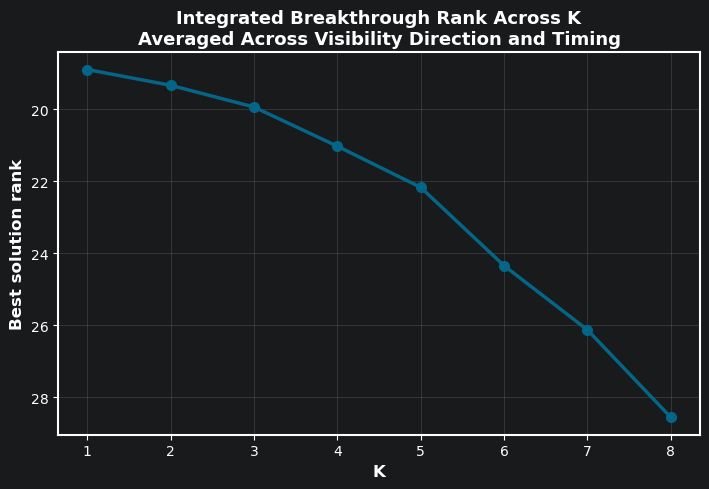

Saved: /Volumes/T7/data/gst-0112-26/Timing_3/figure_8_integrated_breakthrough_rank_across_K.png
Averaged breakthrough rank across K:
K=1: 18.8929
K=2: 19.3307
K=3: 19.9349
K=4: 21.0249
K=5: 22.1679
K=6: 24.3457
K=7: 26.1304
K=8: 28.5608


In [11]:
# =========================
# Figure 8: Integrated breakthrough rank across K
# Averaged across G/S visibility recombinations and visibility timing
# =========================
fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.spines["left"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

dv = "breakthrough_rank"

# Stack arrays with shape:
# condition × visibility_start × K
rank_stack = np.stack(
    [data[prefix][dv] for prefix in condition_order],
    axis=0
)

# Average across:
# axis=0: G/S recombination conditions
# axis=1: visibility timing
# Remaining axis is K
rank_across_K = rank_stack.mean(axis=(0, 1))

ax.plot(
    K_list,
    rank_across_K,
    marker="o",
    linewidth=2.5,
    markersize=7,
    color=morandi_blue
)

ax.set_xlabel("K", fontweight="bold", fontsize=12)
ax.set_ylabel("Best solution rank", fontweight="bold", fontsize=12)
ax.set_title(
    "Integrated Breakthrough Rank Across K\nAveraged Across Visibility Direction and Timing",
    fontweight="bold",
    fontsize=13
)

# Because smaller rank is better: rank 1 is the global best.
ax.invert_yaxis()

ax.grid(alpha=0.25)

plt.tight_layout()

output_path = result_folder / "figure_8_integrated_breakthrough_rank_across_K.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", output_path)
print("Averaged breakthrough rank across K:")
for K, value in zip(K_list, rank_across_K):
    print(f"K={K}: {value:.4f}")
